In [ ]:
def setup():
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import networkx as nx
    import geopandas as gpd
  # asegurate que bases.py esté en el mismo directorio
setup()

import sys
import os
sys.path.append(os.path.abspath("../scripts"))
# nuestro módulo de funciones
import bases

# Notebook de Setup - Proyecto Hospitales

Este notebook explica paso a paso cómo usar las funciones definidas en `bases.py`.  
Se cubrirán:

1. Limpieza y carga de datos
2. Reconstrucción de traslados
3. Análisis individual del paciente
4. Estadísticas y EDA hospitalario
5. Creación y análisis de red hospitalaria
6. Visualización de la red

Cada sección incluye explicación y ejemplos de uso.

## 1. Limpieza y carga de datos

Usamos estas funciones para dejar los datasets listos:

- `cargar_datos_pacientes(path)` → devuelve un DataFrame limpio de pacientes
- `cargar_coordenadas(path)` → devuelve DataFrame de hospitales limpio
- `cargar_municipios(path_shp)` → devuelve GeoDataFrame de municipios con nombres limpios

In [4]:
# ejemplo de carga
df_pacientes = bases.cargar_datos_pacientes("../data/pacientes.xlsx")
df_hosp = bases.cargar_coordenadas("../data/hospitales_coordenadas.csv")
gdf_municipios = bases.cargar_municipios("../data/shapefiles/departamento/departamentoPolygon.shp")


# vista previa
df_pacientes.head()
df_hosp.head()
gdf_municipios.head()

NameError: name 'bases' is not defined

## 2. Reconstrucción de traslados

Funciones útiles:

- `reconstruir_traslados(df)` → genera un DataFrame con los traslados entre hospitales
- `normalizar_hospitales(df)` → limpia nombres de hospitales en cualquier DataFrame

Ejemplo:

In [ ]:
traslados = bases.reconstruir_traslados(df_pacientes)
traslados.head()

,Id Hospital,Nombre Hospital,Id,Fecha inicio,Estado al ingreso,Tipo al ingreso,Último estado,Último tipo,Sexo,Edad,...,Motivo,Operación,Fecha egreso,Última actualización,Duracion días,murio,Hospital siguiente,Fecha ingreso siguiente,dias_entre_hospitales,es_traslado
6528,147,UPA QU,1,2020-05-01 18:07:36,ocupadas_otros,intermedias,ocupadas_otros,intermedias,masculino,36,...,traslado-otro,egreso,2020-08-03 18:07:36,2020-08-04 18:05:01,94.0,False,ONATIVIA,2020-05-19 18:07:35,-77.0,True
3506,8,ONATIVIA,4,2020-05-31 18:07:35,ocupadas_covid,intermedias,ocupadas_covid,intermedias,femenino,17,...,traslado-extra-sanitario,egreso,2020-06-11 18:07:35,2020-07-21 17:34:48,11.0,False,UPA QU,2020-06-08 18:07:36,-3.0,True
6284,146,UPA FV,AB13,2020-08-07 18:07:36,sospechosos,intermedias,sospechosos,intermedias,masculino,56,...,traslado-hospital-de-la-red,egreso,2020-08-10 18:07:36,2020-08-10 21:16:26,3.0,False,MODULO HOSPITALARIO FV,2020-08-10 18:07:34,-1.0,True
6387,146,UPA FV,AB71,2020-09-04 18:07:36,sospechosos,intermedias,sospechosos,intermedias,femenino,NaN,...,traslado-hospital-de-la-red,egreso,2020-09-05 18:07:36,2020-09-05 23:26:22,1.0,False,MODULO HOSPITALARIO FV,2020-09-05 18:07:34,-1.0,True
6332,146,UPA FV,AC92,2020-08-20 18:07:36,sospechosos,intermedias,ocupadas_covid,intermedias,masculino,66,...,traslado-hospital-de-la-red,egreso,2020-08-21 18:07:36,2020-08-21 23:56:08,1.0,False,MODULO HOSPITALARIO FV,2020-08-21 18:07:34,-1.0,True


## 3. Análisis individual del paciente

Funciones:

- `historial_paciente(df, paciente_id)` → muestra todas las internaciones de un paciente
- `historia_clinica(df, paciente_id)` → devuelve un dict con resumen completo y eventos

Ejemplo:

In [ ]:
# historial de un paciente específico
paciente_id = df_pacientes["Id"].iloc[0]
bases.historial_paciente(df_pacientes, paciente_id)
bases.historia_clinica(df_pacientes, paciente_id)

{'paciente_id': 'Mariano',
 'cantidad_internaciones': 1,
 'hospitales_distintos': 1,
 'total_dias_internacion': np.float64(0.0),
 'eventos': [{'hospital': 'EL CRUCE',
   'fecha_inicio': NaT,
   'fecha_egreso': NaT,
   'estado_ingreso': 'sospechosos',
   'tipo_ingreso': 'criticas',
   'motivo': nan,
   'duracion_dias': nan}]}

## 4. Estadísticas y EDA hospitalario

Funciones principales:

- `traslados_por_hospital(df)` → cuenta traslados por hospital
- `tiempo_promedio_por_hospital(df)` → tiempo promedio de estadía
- `muertes_por_hospital(df)` → muertes por hospital
- `distribucion_edades_por_hospital(df)` → estadística descriptiva de edades
- `relacion_tiempo_riesgo_estado(df)` → heatmap de riesgo social vs estado al ingreso

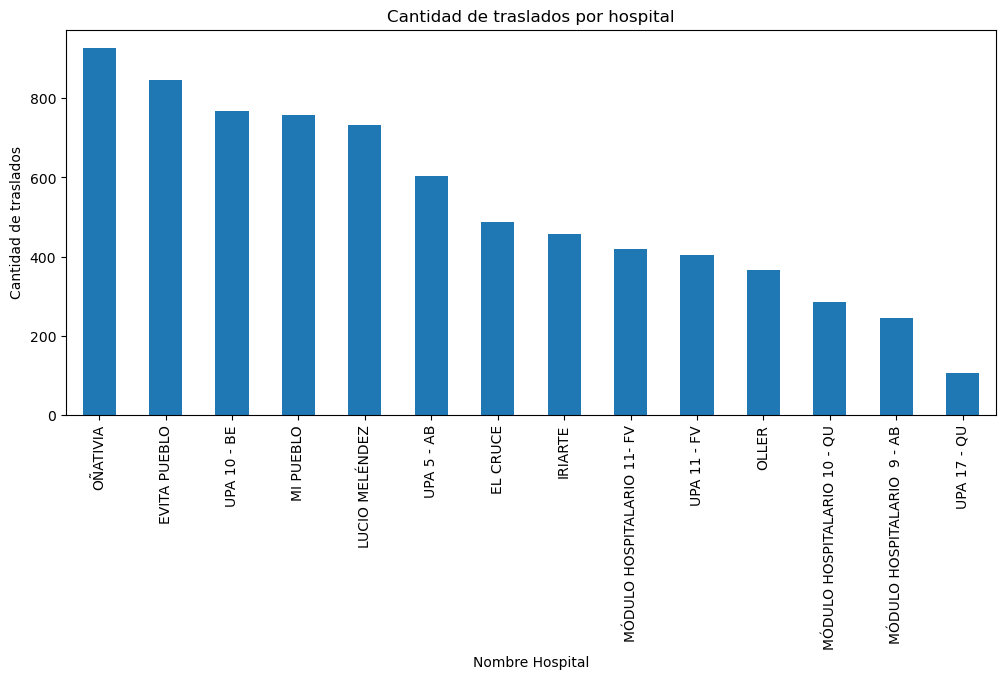

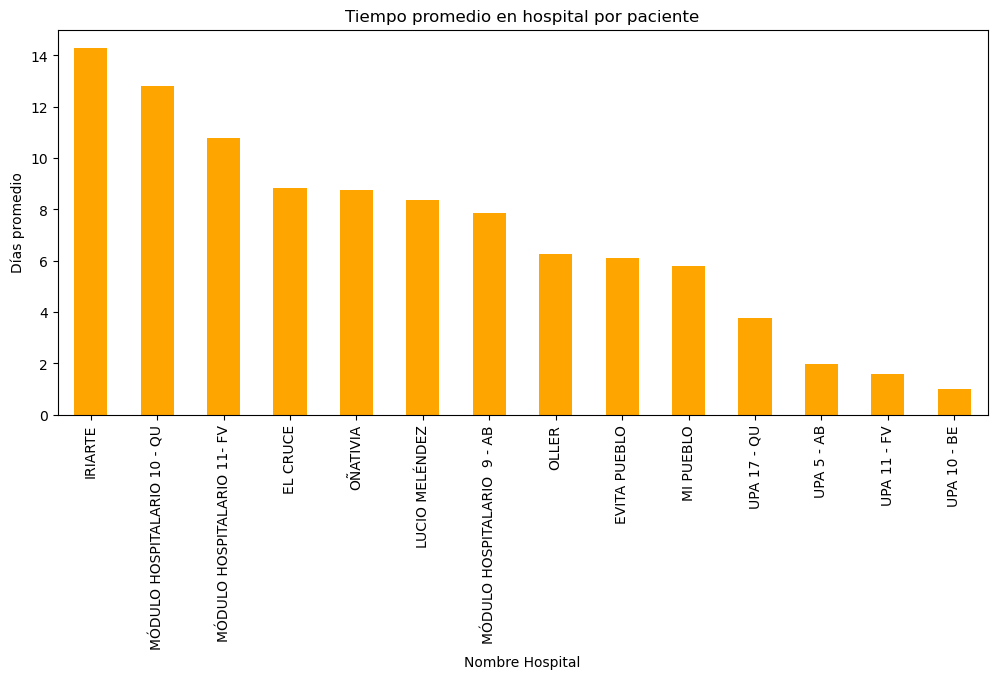

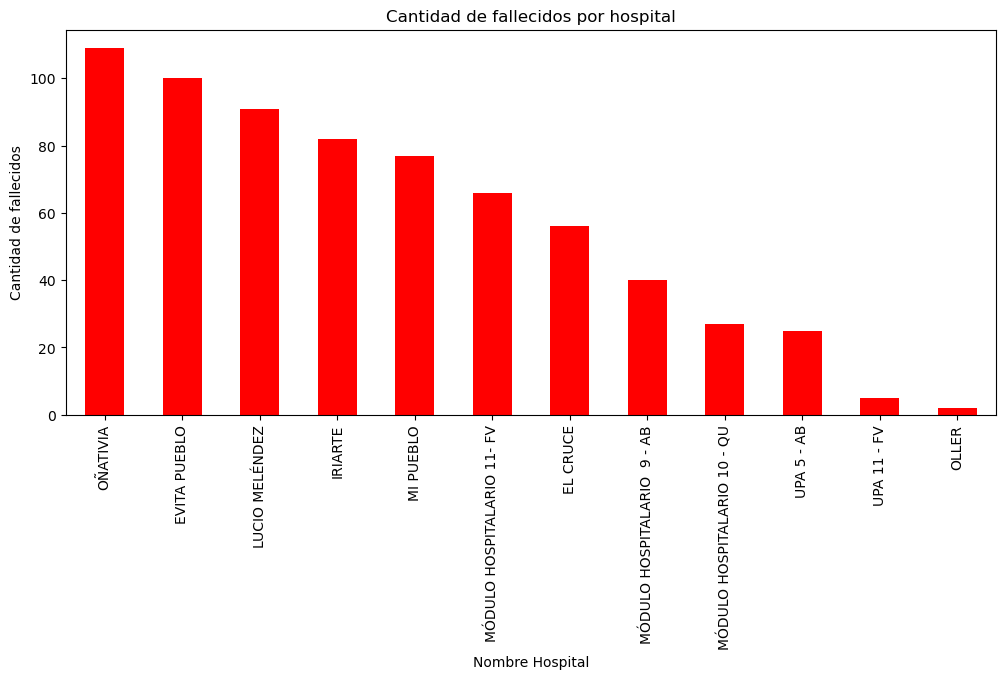

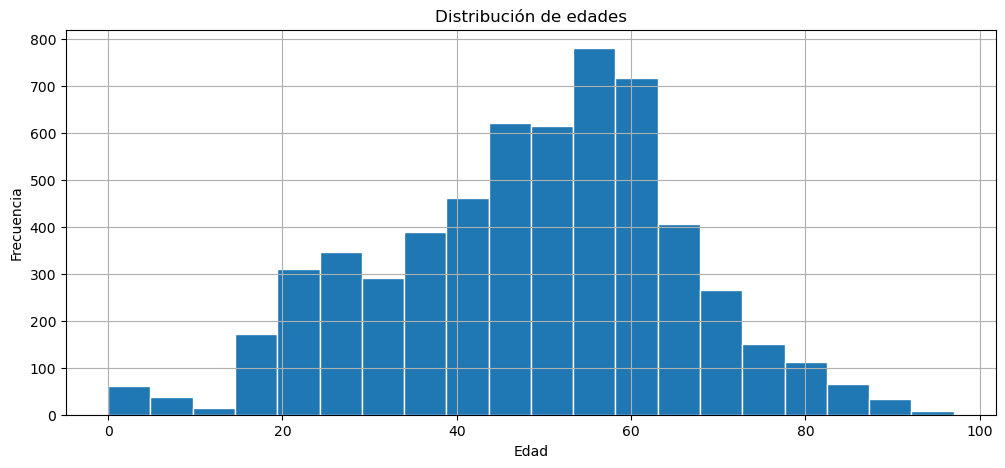

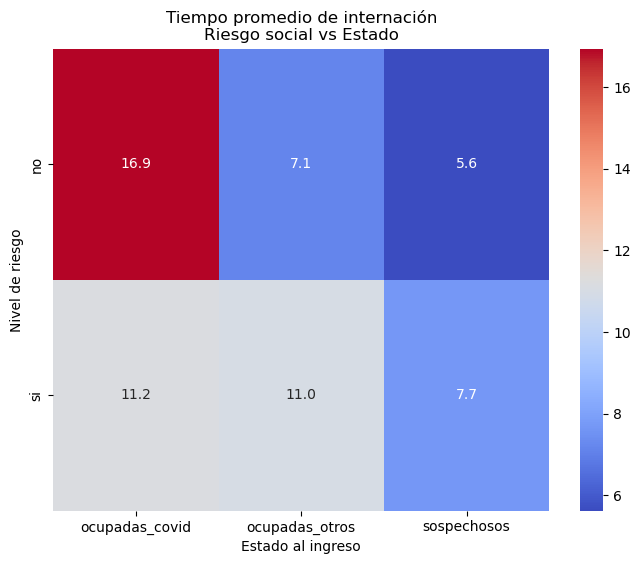

Estado al ingreso,ocupadas_covid,ocupadas_otros,sospechosos
Nivel riesgo social,,,
no,16.946667,7.149533,5.625596
si,11.161631,10.988235,7.682746


In [ ]:
# ejemplos de uso
bases.traslados_por_hospital(df_pacientes)
bases.tiempo_promedio_por_hospital(df_pacientes)
bases.muertes_por_hospital(df_pacientes)
bases.distribucion_edades_por_hospital(df_pacientes)
bases.relacion_tiempo_riesgo_estado(df_pacientes)

## 5. Resúmenes de traslados

Funciones:

- `resumen_traslados(df)` → total y cantidad de hospitales únicos
- `traslados_por_mes(df)` → gráfica traslados por mes
- `traslados_en_el_tiempo(df)` → serie temporal de traslados
- `distribucion_traslados_paciente(df)` → histogramas y estadísticas de pacientes
- `tiempo_total_paciente(df)` → total de días en el sistema por paciente

Total de traslados: 496
Cantidad de hospitales únicos: 12


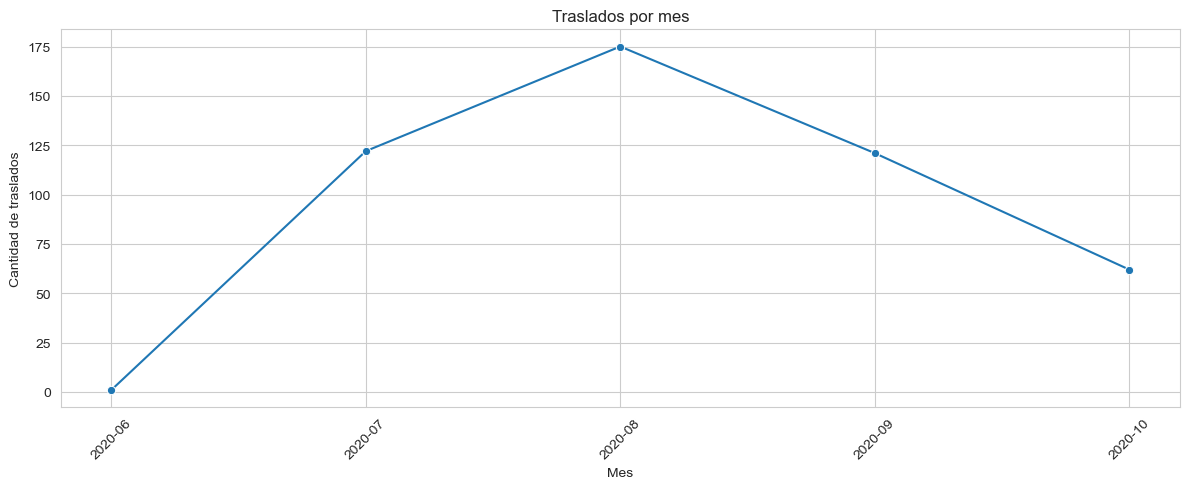

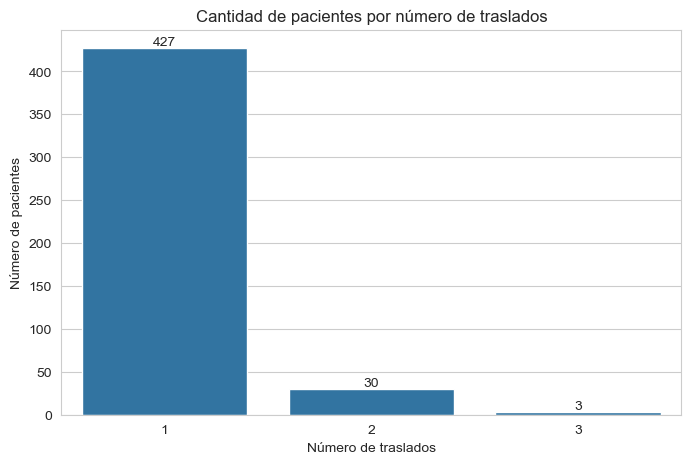

Promedio de traslados por paciente: 1.0782608695652174
Desvío estándar: 0.29217316878347405


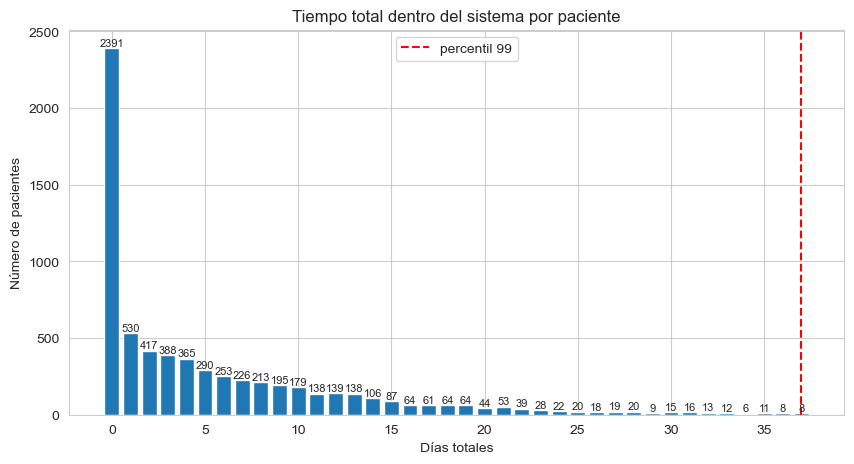

(Id
 4       26.0
 5       23.0
 6       20.0
 7        0.0
 10       6.0
         ... 
 ZZ56     0.0
 ZZ71     0.0
 ZZ77    10.0
 ZZ78     4.0
 ZZ88     0.0
 Name: Duracion días, Length: 6733, dtype: float64,
 np.float64(37.0))

In [ ]:
# ejemplos
bases.resumen_traslados(traslados)
bases.traslados_por_mes(traslados)
bases.distribucion_traslados_paciente(traslados)
bases.tiempo_total_paciente(df_pacientes)

## 6. Creación y análisis de red hospitalaria

Funciones principales:

- `analizar_red_hospitalaria(...)` → aplica filtros y devuelve graficado o la red
- `metricas_red(G)` → calcula métricas de centralidad
- `top_flujos_hospitales(traslados)` → top traslados entre hospitales
- `gdf_red_hospitalaria(G, hosp_coords)` → prepara GeoDataFrames para visualizar

Registros luego de filtros: 496
Hospitales origen únicos: 12
Hospitales destino únicos: 12
Nodos en red: 13
Aristas en red: 40
Top hospitales por betweenness:
                     hospital  degree_centrality  betweenness  in_degree  \
0                    EL CRUCE           1.166667     0.477273         45   
4    MODULO HOSPITALARIO   QU           0.750000     0.333333         38   
11                   ONATIVIA           0.666667     0.250000          2   
9                    UPA   QU           0.416667     0.106061          5   
3   MODULO HOSPITALARIO    AB           0.666667     0.083333        110   
1              LUCIO MELENDEZ           0.500000     0.075758         24   
2                   MI PUEBLO           0.583333     0.064394         16   
5     MODULO HOSPITALARIO  FV           0.500000     0.000000        210   
6                    UPA   FV           0.500000     0.000000         23   
8                     IRIARTE           0.333333     0.000000          6   

    

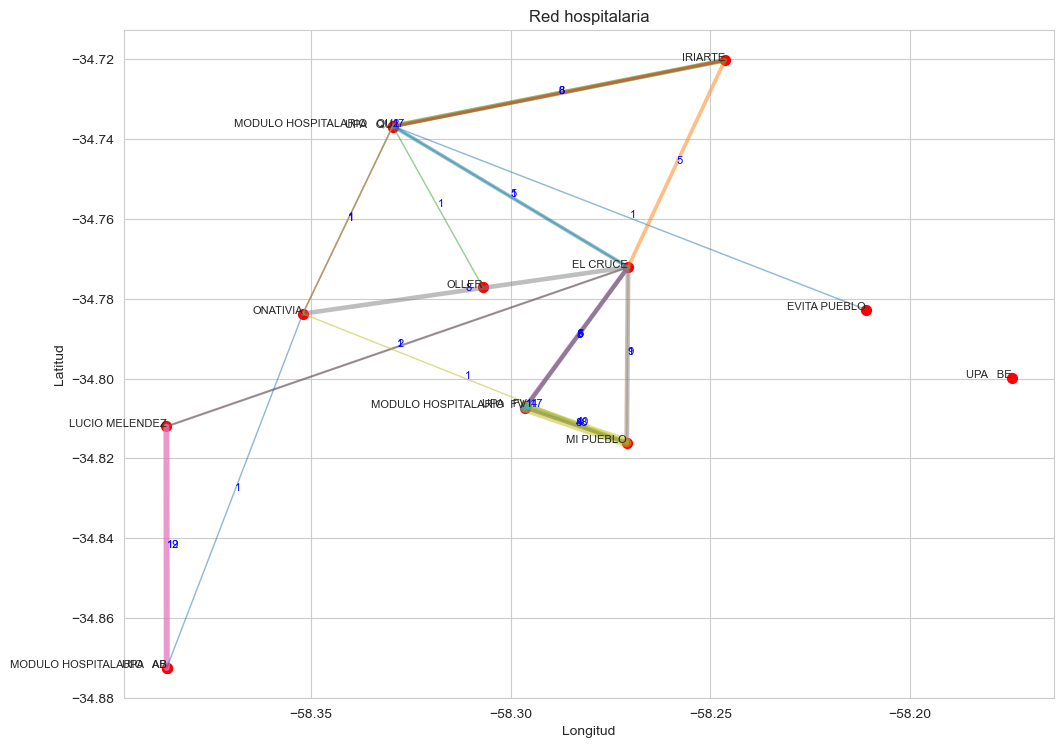

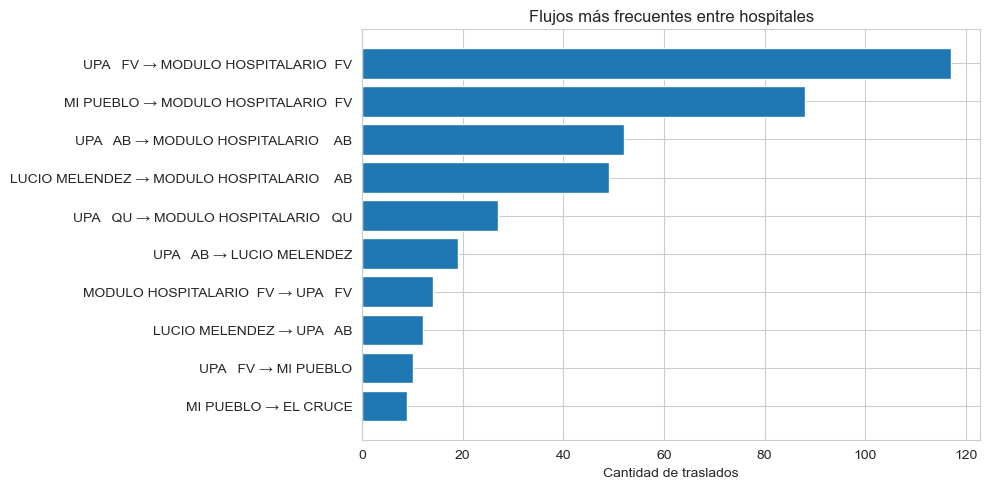

Ignorados (no encontrados en hosp_coords): {'MODULO HOSPITALARIO    AB'}


In [ ]:
# reconstrucción de la red
G, edges, fig_tuple = bases.analizar_red_hospitalaria(
    traslados, 
    hosp_coords=df_hosp, 
    modo="estatico",
    graficar=True
)


# métricas
df_metricas = bases.metricas_red(G)
top_flujos = bases.top_flujos_hospitales(traslados)
gdf_edges, gdf_nodes = bases.gdf_red_hospitalaria(G, df_hosp)

# la figura se puede mostrar con
if fig_tuple:  
    # suponiendo que es (fig, ax)
    fig, ax = fig_tuple  
    plt.show()  # o plt.show() si es matplotlib  # o plt.show() si es matplotlib

## 7. Visualización de red hospitalaria

Funciones:

- `plot_edges_geo(G, hosp_coords)` → red estática simple
- `plot_red_con_mapa(G, hosp_coords)` → red sobre mapa con basemap
- `plot_red_interactiva(G, hosp_coords)` → red interactiva con folium
- `plot_red_sobre_amba(gdf_edges, gdf_nodes, municipios_amba)` → red sobre el AMBA

Ejemplo:

Estos hospitales no están en hosp_coords y se ignoraron: {'MODULO HOSPITALARIO    AB'}


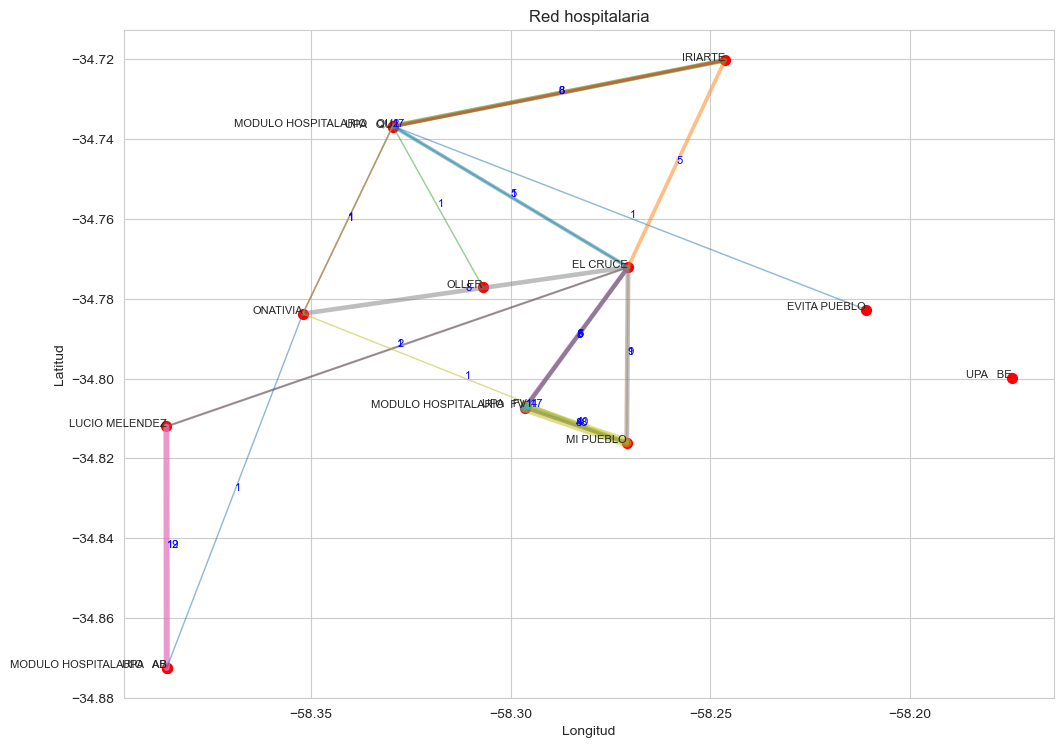

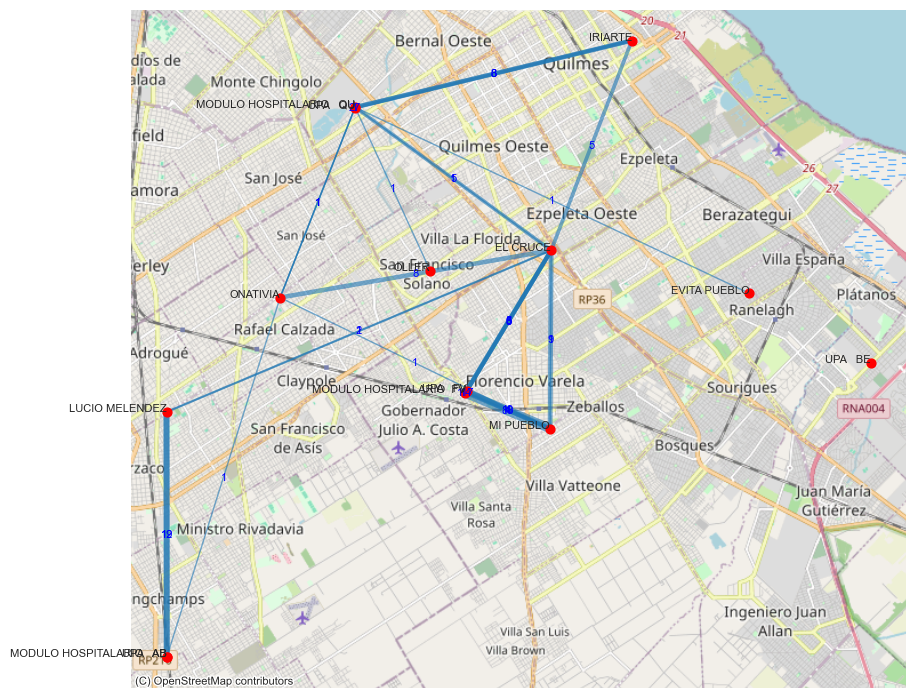

In [ ]:
# visualización estática
bases.plot_edges_geo(G, df_hosp)

# visualización sobre mapa
bases.plot_red_con_mapa(G, df_hosp)

# visualización interactiva
mapa = bases.plot_red_interactiva(G, df_hosp)
mapa  # en Jupyter se muestra interactivo

# Borradores

### Metricas estructurales

In [ ]:
# print("Nodos:", G_periodo.number_of_nodes())
# print("Aristas:", G_periodo.number_of_edges())
# print("Densidad:", nx.density(G_periodo))
# print("Componentes débiles:", nx.number_weakly_connected_components(G_periodo))

## Modulo 2: Analisis individual del paciente

### a. Historial paciente (version simple)

In [ ]:
# def historial_paciente(df, paciente_id):
#     df_p = df[df["Id"] == paciente_id].sort_values("Fecha inicio")
#     historia = df_p[[
#         "Nombre Hospital","Fecha inicio","Fecha egreso",
#         "Estado al ingreso","Tipo al ingreso","Motivo","Duracion días"
#     ]]
#     return historia

### b. Historial clinico (version estructurada, como Objeto)

In [ ]:
# def historia_clinica(df, paciente_id):
#     df_p = df[df["Id"] == paciente_id].sort_values("Fecha inicio")
#     historia = {
#         "paciente_id": paciente_id,
#         "cantidad_internaciones": len(df_p),
#         "hospitales_distintos": df_p["Nombre Hospital"].nunique(),
#         "total_dias_internacion": df_p["Duracion días"].sum(),
#         "eventos": []
#     }
#     for _, row in df_p.iterrows():
#         historia["eventos"].append({
#             "hospital": row["Nombre Hospital"],
#             "fecha_inicio": row["Fecha inicio"],
#             "fecha_egreso": row["Fecha egreso"],
#             "estado_ingreso": row["Estado al ingreso"],
#             "tipo_ingreso": row["Tipo al ingreso"],
#             "motivo": row["Motivo"],
#             "duracion_dias": row["Duracion días"]
#         })
#     return historia

## Modulo 3: analisis

In [ ]:
# G, edges = generar_red(traslados, "2020-06-01", "2020-10-31")

# # grado ponderado de entrada y salida
# in_strength = dict(G.in_degree(weight="weight"))
# out_strength = dict(G.out_degree(weight="weight"))

### a. Hospitales que mas reciben/derivan pacientes de traslados

In [ ]:
# print("Top 5 hospitales que más reciben derivaciones:")
# for hosp, val in sorted(in_strength.items(), key=lambda x: x[1], reverse=True)[:5]:
#     print(f"{hosp}: {val} derivaciones")


# print("\nTop 5 hospitales que más derivan pacientes:")
# for hosp, val in sorted(out_strength.items(), key=lambda x: x[1], reverse=True)[:5]:
#     print(f"{hosp}: {val} derivaciones")

### b. Top 5 betweenness centrality

La betweenness centrality mide qué hospitales actúan como intermediarios estructurales en la red de derivaciones

In [ ]:
# bet = nx.betweenness_centrality(G, weight="weight")
# print("\nTop 5 hospitales según betweenness centrality:")
# for hosp, val in sorted(bet.items(), key=lambda x: x[1], reverse=True)[:5]:
#     print(f"{hosp}: {val:.4f}")

### C. La red es jerárquica o distribuida?

In [ ]:
# print("\nDensidad de la red:", nx.density(G)) #densidad baja: jerarquica
# print("Componentes débiles:", nx.number_weakly_connected_components(G)) # pocos componentes: sistema NO fragmentado

### d. tiempo promedio entre hospitales

In [ ]:
# # tiempo entre hospitales
# dias = traslados["dias_entre_hospitales"]
# print("\nResumen días entre hospitales:")
# print(dias.describe())
# print("Promedio días entre hospitales:", dias.mean())

### e. Histograma

In [ ]:
# plt.figure(figsize=(8,5))
# dias.hist(bins=20, color="#4C72B0")
# plt.title("Distribución de días entre hospitales")
# plt.xlabel("Días entre egreso e ingreso siguiente")
# plt.ylabel("Cantidad de traslados")
# plt.grid(axis='y', alpha=0.3)
# plt.show()

### Problema que encontre:
hay algunos casos donde me estan dando tiempos negativos de traslados. Estudiarlo mas

In [ ]:
# # Ver qué filas generan negativos

# negativos = traslados[traslados["dias_entre_hospitales"] < 0][[
#     "Id",
#     "Nombre Hospital",
#     "Hospital siguiente",
#     "Fecha egreso",
#     "Fecha ingreso siguiente",
#     "Motivo",
#     "dias_entre_hospitales"
# ]]

# print(len(negativos), "traslados con días negativos entre hospitales")
# print(len(traslados), "traslados totales")
# # mostrar las primeras filas
# negativos.sort_values("dias_entre_hospitales").head(20)

In [ ]:
# # Contar cuántos negativos son realmente traslados

# neg_traslados = negativos[negativos["Motivo"].str.contains("traslado", case=False, na=False)]
# print("Negativos que son traslados reales:", len(neg_traslados))

In [ ]:
'''# opciones para resolver

# 1. Ignorar valores negativos (para análisis de tiempos promedio entre hospitales):
traslados["dias_entre_hospitales"] = traslados["dias_entre_hospitales"].clip(lower=0)
# 2. Eliminar los traslados raros
traslados = traslados[~((traslados["dias_entre_hospitales"] < 0) & (traslados["Motivo"].str.contains("traslado", case=False, na=False)))]
# 3. Ver caso por caso que paso'''

'# opciones para resolver\n\n# 1. Ignorar valores negativos (para análisis de tiempos promedio entre hospitales):\ntraslados["dias_entre_hospitales"] = traslados["dias_entre_hospitales"].clip(lower=0)\n# 2. Eliminar los traslados raros\ntraslados = traslados[~((traslados["dias_entre_hospitales"] < 0) & (traslados["Motivo"].str.contains("traslado", case=False, na=False)))]\n# 3. Ver caso por caso que paso'